In [539]:
# Import all necessary libraries for data analysis and machine learning
import numpy as np  # for numerical operations and arrays
import pandas as pd  # for data manipulation and dataframes
import scipy  # for scientific computing
from scipy import stats  # for statistical tests
from scipy.stats import norm, t, binom, poisson, expon, chi2, f  # specific statistical distributions
import matplotlib.pyplot as plt  # for creating plots and visualizations
import seaborn as sns  # for enhanced statistical visualizations
import statsmodels  # for statistical modeling
import statsmodels.api as sm  # for regression models (OLS, Logit, etc.)
from statsmodels import stats as sm_stats  # for statistical tests
from statsmodels.stats import weightstats as sswa  # for weighted statistics
from statsmodels.formula.api import ols  # for ordinary least squares regression with formulas
from statsmodels.stats.multicomp import pairwise_tukeyhsd  # for post-hoc ANOVA tests
from statsmodels.stats import proportion as ssp  # for proportion tests
from statsmodels.stats.proportion import proportions_ztest  # for z-test on proportions
import os  # for file and directory operations
import warnings  # to manage warning messages
warnings.filterwarnings("ignore")  # suppress warning messages for cleaner output
from scipy.stats import chi2_contingency  # for chi-square test of independence
from sklearn.model_selection import train_test_split  # to split data into training and testing sets
from sklearn.linear_model import LinearRegression  # for linear regression modeling
from sklearn.metrics import confusion_matrix

In [540]:
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

In [541]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name = 'diabetes')

In [542]:
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,DietType
0,148,72,35,0,33.6,0.63,50,1,1
1,85,66,29,0,26.6,0.35,31,0,2
2,183,64,0,0,23.3,0.67,32,1,1
3,89,66,23,94,28.1,0.17,21,0,1
4,137,40,35,168,43.1,2.29,33,1,1


<Axes: xlabel='DietType'>

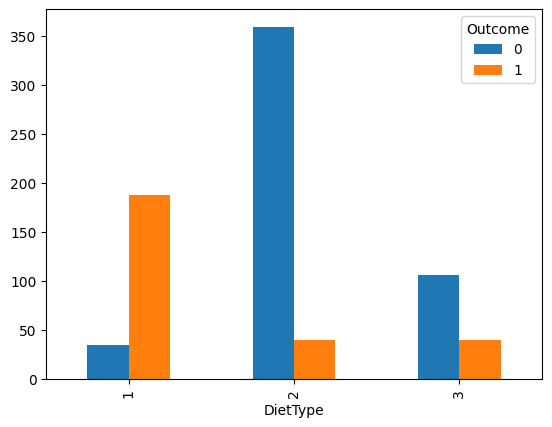

In [543]:
pd.crosstab(df.DietType, df.Outcome).plot(kind = 'bar')

In [544]:
pd.crosstab(df.DietType, df.Outcome)

Outcome,0,1
DietType,,
1,35,188
2,359,40
3,106,40


In [545]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name = 'nominal')

In [546]:
df = df.drop('write', axis =1)

In [547]:
df.head()

,ses,math,prog
0,1,41,1
1,2,41,2
2,3,44,3
3,1,42,1
4,2,40,2


In [548]:
np.unique(df['ses'])

array([1, 2, 3])

In [549]:
mydf= pd.crosstab(df.ses, df.prog)

In [550]:
mydf

prog,1,2,3
ses,,,
1,29,16,2
2,6,51,38
3,1,9,48


In [551]:
scipy.stats.chi2_contingency(mydf)

Chi2ContingencyResult(statistic=np.float64(116.68974607356007), pvalue=np.float64(2.719736300260215e-24), dof=4, expected_freq=array([[ 8.46, 17.86, 20.68],
       [17.1 , 36.1 , 41.8 ],
       [10.44, 22.04, 25.52]]))

In [552]:
# degree of 

<Axes: xlabel='ses'>

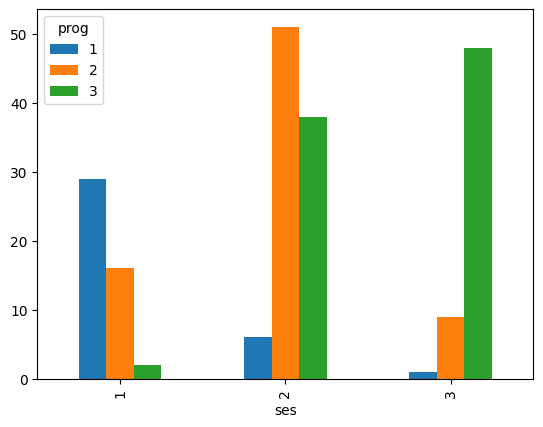

In [553]:
pd.crosstab(df.ses, df.prog).plot(kind ='bar')

In [554]:
from statsmodels import discrete
from statsmodels.discrete import discrete_model
from statsmodels.discrete.discrete_model import MNLogit

```text
                ┌───────────────────────────────┐
                │           DATASET             │
                └───────────────────────────────┘
                          │
                          ▼
                ┌───────────────────────────────┐
                │        Train–Test Split        │
                └───────────────────────────────┘
                          │
         ┌────────────────┴────────────────┐
         ▼                                 ▼
┌──────────────────────┐        ┌──────────────────────┐
│       TRAINING        │        │        TESTING       │
└──────────────────────┘        └──────────────────────┘
         │                                 │
         ▼                                 ▼
┌──────────────────────┐        ┌──────────────────────┐
│   x_train (inputs)    │        │   x_test (inputs)    │
└──────────────────────┘        └──────────────────────┘
         │                                 │
         ▼                                 ▼
┌──────────────────────┐        ┌──────────────────────┐
│   y_train (labels)    │        │   y_test (labels)    │
└──────────────────────┘        └──────────────────────┘
         │                                 │
         ▼                                 ▼
┌──────────────────────┐        ┌──────────────────────────────┐
│  Model learns from    │        │ Model predicts y_pred from    │
│ x_train → y_train     │        │         x_test               │
└──────────────────────┘        └──────────────────────────────┘
                                            │
                                            ▼
                              ┌──────────────────────────────┐
                              │ Compare y_pred with y_test   │
                              │ → accuracy, error, metrics   │
                              └──────────────────────────────┘

In [555]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='nominal')

# Drop unnecessary column
df = df.drop('write', axis=1)

# Create dummy variables for 'ses' (only once)
xses_dummy = pd.get_dummies(df.ses, prefix='ses', drop_first=True).astype(int)
df = df.drop('ses', axis=1)
df = pd.concat([df, xses_dummy], axis=1)

# Split data
x_train, x_test, y_train, y_test = train_test_split(df.drop('prog', axis=1), df.prog, random_state=20, test_size=0.1)

# Add constant for intercept
x_train = sm.add_constant(x_train, prepend=False)

# Fit multinomial logistic regression
mod1 = sm.MNLogit(y_train, x_train).fit()
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.675417
         Iterations 7
                          MNLogit Regression Results                          
Dep. Variable:                   prog   No. Observations:                  180
Model:                        MNLogit   Df Residuals:                      172
Method:                           MLE   Df Model:                            6
Date:                Thu, 11 Dec 2025   Pseudo R-squ.:                  0.3460
Time:                        18:11:50   Log-Likelihood:                -121.58
converged:                       True   LL-Null:                       -185.89
Covariance Type:            nonrobust   LLR p-value:                 2.508e-25
    prog=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
math           0.0162      0.034      0.480      0.631      -0.050       0.082
ses_2          2.7883      0.

In [556]:
# in prog 2

#  p-value of math (0.631) is much greater than 0.05, you fail to reject the null hypothesis.

### Why do we reject if the p-value is less than 0.05?

In hypothesis testing, the p-value tells us how likely it is to observe our data if the null hypothesis is true.

- If the p-value is **less than 0.05** (the typical significance level), it means the result is unlikely under the null hypothesis, so we **reject the null hypothesis**.
- If the p-value is **greater than 0.05**, we do **not** have enough evidence to reject the null hypothesis.

**Note:** The value 0.5 is not used for decision-making. The standard threshold is 0.05.

#### Example for prog 2:
- The p-value for math is **0.631**, which is much greater than 0.05.
- Therefore, we **fail to reject the null hypothesis**: the math score does not significantly influence the choice between prog1 and prog2.

In [557]:
# in prog 3

# p-value of math (0.001) is much less than 0.05, you reject the null hypothesis.

In [558]:
# H0-the maths score does not influence the choice between prog1(ref) ad prog2(target)
# the probablity of choosing prog2 (target) over prog1 (ref) is not influenced by the maths score

In [559]:
# Ho of ses_2 of prog2 the probablity of choosing prog2 (target) over prog1 (ref) is not influenced if the ses is changed from ses_1 (ref1) to ses_2 target

In [560]:
# the probablity of choosing prog 2 over prog 1 is not influenced the choice from ses1 and ses2

In [561]:
# the ses2 has higher probablity of choosing the program 3 over program 1 because coef (ses2 > ses1)
# the ses3 has higher probablity of choosing the program 3 over program 1 because coef (ses2 > ses1)

In [562]:
x_test = sm.add_constant(x_test, prepend = False)

In [563]:
x_test = sm.add_constant(x_test, prepend = False)

In [564]:
y_pred = mod1.predict(x_test)

In [565]:
y_pred[:2]

,0,1,2
150,0.026359,0.322718,0.650923
28,0.619435,0.359926,0.020638


In [566]:
x_test[:2]

,math,ses_2,ses_3,const
150,62,1,0,1.0
28,46,0,0,1.0


In [567]:
mod1.params

,0,1
math,0.016225,0.134253
ses_2,2.788273,4.460186
ses_3,2.585898,6.328332
const,-1.289248,-9.577303


In [568]:
# Manual calculation of predicted probabilities for a student with math=62
math_score = 62

# For Prog2 vs Prog1 (reference)
# Linear predictor: coef_math*math + intercept + other_terms (if any)
logit_prog2 = 0.016225 * math_score + 2.7883 - 1.289248  # Example: math coef, intercept, and other term
print('Logit (Prog2 vs Prog1):', logit_prog2)

# Convert logit to odds (exponentiate)
odds_prog2 = np.exp(logit_prog2)
print('Odds (Prog2 vs Prog1):', odds_prog2)

# For Prog3 vs Prog1 (reference)
logit_prog3 = 0.134253 * math_score + 4.4602 - 9.5773
print('Logit (Prog3 vs Prog1):', logit_prog3)

odds_prog3 = np.exp(logit_prog3)
print('Odds (Prog3 vs Prog1):', odds_prog3)

# The denominator for softmax (sum of all odds, including reference category which is always 1)
denominator = 1 + odds_prog2 + odds_prog3
print('Denominator (sum of odds):', denominator)

# Predicted probabilities for each program
prob_prog1 = 1 / denominator
prob_prog2 = odds_prog2 / denominator
prob_prog3 = odds_prog3 / denominator



# this will result in prog1 + prog2 + prog3     = 1
print('Probability of Prog1:', prob_prog1)
print('Probability of Prog2:', prob_prog2)
print('Probability of Prog3:', prob_prog3)

print(prob_prog1 + prob_prog2 + prob_prog3)

Logit (Prog2 vs Prog1): 2.505002
Odds (Prog2 vs Prog1): 12.243583452943447
Logit (Prog3 vs Prog1): 3.2065860000000015
Odds (Prog3 vs Prog1): 24.69463466505546
Denominator (sum of odds): 37.93821811799891
Probability of Prog1: 0.026358644385714395
Probability of Prog2: 0.3227242622429535
Probability of Prog3: 0.6509170933713322
1.0


In [569]:
score = 46

x = 0.016225 * score + 2.7883 - 1.289248


In [570]:
1/37.9488

0.026351294375579728

In [571]:
12.2537/37/9488

3.490525728088966e-05

In [572]:
24.6951/37.9488

0.6507478497343789

In [573]:
mydata = pd.DataFrame([[70,0,0,1],
                       [70,1,0,1],
                       [70,0,1,1]], columns = x_train.columns)

mypred = mod1.predict(mydata)

In [574]:
(np.log(0.940862/0.003400) - np.log(0.594971/0.031514))

np.float64(2.6849402713892214)

In [575]:
(np.log(0.940862/0.003400) - np.log(0.594971/0.031514))/20     # divide by 20 because difference of marks is 20 (80-60)

np.float64(0.13424701356946106)

In [576]:
(np.log(0.828716/0.011465) - np.log(0.5949710/0.031514))/10

np.float64(0.13424978253854344)

In [577]:
print(mod1.summary())

                          MNLogit Regression Results                          
Dep. Variable:                   prog   No. Observations:                  180
Model:                        MNLogit   Df Residuals:                      172
Method:                           MLE   Df Model:                            6
Date:                Thu, 11 Dec 2025   Pseudo R-squ.:                  0.3460
Time:                        18:11:50   Log-Likelihood:                -121.58
converged:                       True   LL-Null:                       -185.89
Covariance Type:            nonrobust   LLR p-value:                 2.508e-25
    prog=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
math           0.0162      0.034      0.480      0.631      -0.050       0.082
ses_2          2.7883      0.572      4.871      0.000       1.666       3.910
ses_3          2.5859      1.110      2.329      0.0

In [578]:
mydata

,math,ses_2,ses_3,const
0,70,0,0,1
1,70,1,0,1
2,70,0,1,1


In [579]:
mypred = mod1.predict(mydata)

In [580]:
mypred

,0,1,2
0,0.371292,0.318452,0.310256
1,0.011465,0.159819,0.828716
2,0.002081,0.023695,0.974223


In [581]:
(np.log(0.828716/0.011465)- np.log(0.310256/0.371292))

np.float64(4.460169650598519)

In [582]:
(np.log(0.974223/0.002081) - np.log(0.310256/0.371292))

np.float64(6.32838273468834)

In [583]:
y_pred_event = []

for ctr in range(y_pred.shape[0]):
    y_pred_event.append(np.argsort(y_pred.iloc[ctr])[::-1].iloc[0]+1)

In [584]:
print(confusion_matrix(y_test, y_pred_event))

[[ 3  1  1]
 [ 1  1  2]
 [ 0  1 10]]


#### ordinal logistic regression

In [585]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name = 'ordinal')

In [586]:
df.head()

,Survival,Region,ToxicLevel
0,1,1,62.0
1,1,2,46.0
2,2,1,48.5
3,3,2,32.0
4,2,1,63.5


In [587]:
# Poisson - less counts variation
# Negative binomial - when the more count variation

In [588]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

In [589]:

reg_dummy = pd.get_dummies(df.Region,prefix='Region',drop_first=True).astype(int)
df = df.drop('Region', axis=1)
df=pd.concat([df,reg_dummy], axis=1)

In [590]:
df.Survival = pd.Categorical(df.Survival, ordered=True)
x_train,x_test,y_train,y_test = train_test_split(df.drop('Survival',axis=1), df.Survival, random_state = 20, test_size=0.1)

#x_train = sm.add_constant(x_train, prepend=False)
mod1 = OrderedModel(y_train,x_train,distr='logit').fit(method='bfgs')
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.825416
         Iterations: 19
         Function evaluations: 22
         Gradient evaluations: 22
                             OrderedModel Results                             
Dep. Variable:               Survival   Log-Likelihood:                -53.652
Model:                   OrderedModel   AIC:                             115.3
Method:            Maximum Likelihood   BIC:                             124.0
Date:                Thu, 11 Dec 2025                                         
Time:                        18:11:50                                         
No. Observations:                  65                                         
Df Residuals:                      61                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [591]:
# survivial rating is independent in which region wherever we are
# H0 - moving from region 1 to region 2 doens't influence survival rating
# 

In [592]:
mydata = pd.DataFrame([[30,1],[50,1],[70,1],[80,1],[100,1]], columns=x_train.columns)        # custom toxicity levels 30->50->70

In [593]:
# Rename columns for clarity: 'toxicity_level' and 'region_2'
mydata = pd.DataFrame([[30,1],[50,1],[70,1],[80,1],[100,1]], columns=['toxicity_level', 'region_2'])
mydata

# Predict survival probabilities for each toxicity level
mypred = mod1.predict(mydata)
mypred  # Each column is a survival rating, each row is a toxicity level

,0,1,2
0,0.040666,0.527811,0.431523
1,0.345596,0.596973,0.057431
2,0.868062,0.127071,0.004867
3,0.958716,0.039900,0.001384
4,0.996555,0.003333,0.000111


In [594]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name = 'poisson')

In [595]:
df.head()

,num_awards,prog,math
0,0,3,41
1,0,1,41
2,0,3,44
3,0,3,42
4,0,3,40


In [596]:
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import Poisson as psn

In [597]:
prog_dummy = pd.get_dummies(df.prog,prefix='prog',drop_first=True).astype(int)
df = df.drop('prog', axis=1)
df=pd.concat([df,prog_dummy], axis=1)

In [598]:
df.head()

,num_awards,math,prog_2,prog_3
0,0,41,0,1
1,0,41,0,0
2,0,44,0,1
3,0,42,0,1
4,0,40,0,1


In [599]:
#df.Survival = pd.Categorical(df.Survival, ordered=True)
x_train,x_test,y_train,y_test = train_test_split(df.drop('num_awards',axis=1), df.num_awards, \
random_state = 20, test_size=0.1)
    

In [600]:
x_train = sm.add_constant(x_train, prepend=False)

df_train = pd.concat([x_train,y_train], axis=1)
#x_train = sm.add_constant(x_train, prepend=False)
mod1 = psn.from_formula("num_awards ~ math+prog_2+prog_3", data=df_train).fit()
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.879422
         Iterations 6
                          Poisson Regression Results                          
Dep. Variable:             num_awards   No. Observations:                  180
Model:                        Poisson   Df Residuals:                      176
Method:                           MLE   Df Model:                            3
Date:                Thu, 11 Dec 2025   Pseudo R-squ.:                  0.1915
Time:                        18:11:50   Log-Likelihood:                -158.30
converged:                       True   LL-Null:                       -195.79
Covariance Type:            nonrobust   LLR p-value:                 3.634e-16
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.1566      0.738     -6.990      0.000      -6.603      -3.711
math           0.0674      0.

##### negative binomial

In [601]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name = 'neg_bin')

In [602]:
df.head()

,math,prog,daysabs
0,63,Academic,4
1,27,Academic,4
2,20,Academic,2
3,16,Academic,3
4,2,Academic,3


In [603]:
list(np.unique(df['prog']))

['Academic', 'General', 'Vocational']

In [604]:
from statsmodels.discrete.discrete_model import NegativeBinomial as ngb

prog_dummy = pd.get_dummies(df.prog,drop_first=True).astype(int)
df = df.drop('prog', axis=1)
df=pd.concat([df,prog_dummy], axis=1)

#df.Survival = pd.Categorical(df.Survival, ordered=True)
x_train,x_test,y_train,y_test = train_test_split(df.drop('daysabs',axis=1), df.daysabs, random_state = 20, test_size=0.1)
    
x_train = sm.add_constant(x_train, prepend=False)

df_train = pd.concat([x_train,y_train], axis=1)
#x_train = sm.add_constant(x_train, prepend=False)
mod1 = ngb.from_formula("daysabs ~ math+General+Vocational", data=df_train).fit()
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 2.816981
         Iterations: 20
         Function evaluations: 26
         Gradient evaluations: 26
                     NegativeBinomial Regression Results                      
Dep. Variable:                daysabs   No. Observations:                  282
Model:               NegativeBinomial   Df Residuals:                      278
Method:                           MLE   Df Model:                            3
Date:                Thu, 11 Dec 2025   Pseudo R-squ.:                 0.03004
Time:                        18:11:51   Log-Likelihood:                -794.39
converged:                       True   LL-Null:                       -818.99
Covariance Type:            nonrobust   LLR p-value:                 1.176e-10
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1705      0.137     1

- α > 0 indicates overdispersion (variance greater than mean).
- α = 0
- α = 0 means no overdispersion (reduces to Poisson).

In [607]:
print(10 and 20)

20
